# Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **_Hardani Ismu Nabil_** | _hardani.ismu.n@gmail.com_ | **_ND Stadium Collaborative Project 2025/2026_** |

# Notebook Target Definition

* **GENERATES** graphs for PDSCH and PUSCH MCS index in all day observation

# ===============================
# ===============================

# A- Notebook Setup

In [1]:
# %pip install pandas numpy matplotlib pathlib

In [2]:

import os
import pathlib

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Force Matplotlib to use Type 42 (TrueType) fonts instead of Type 3
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Ensure text isn't converted to paths/bitmaps
matplotlib.rcParams['svg.fonttype'] = 'none'


### B: ECDF single

In [3]:
PROJECT_ROOT = pathlib.Path('.').cwd().parent # you can also do it manually, for example ~/repos/NdSta2026


print('='*50, '[DATA DIRECTORY]')
DATA_DIR2 = PROJECT_ROOT / "data_raw/ND_STA_2026"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR2}")

print('='*50, '[DATA DIRECTORY]')
DATA_DIR3 = PROJECT_ROOT / "data_raw/ND_STA_2025"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR3}")


print('- '*25)
print('='*50, '[OUTPUT DIRECTORY]')

# OUTPUT_DIR = PROJECT_ROOT / 'output/output_May25th/phy-qoe_browsingBandAnalysis' # CHANGE this into the notebook file name
OUTPUT_DIR = PROJECT_ROOT / 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"All outputs will be in: {OUTPUT_DIR}")

================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026
================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================================== [OUTPUT DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
All outputs will be in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/figures


In [4]:
lte_pdsch_agg25 = pd.read_csv(DATA_DIR3 / "lte_pdsch_agg.csv")
lte_pdsch_agg25['Technology'] = 'LTE'
nr_pdsch_agg25 = pd.read_csv(DATA_DIR3 / "nr_pdsch_agg.csv")
nr_pdsch_agg25['Technology'] = '5G NR'

lte_pdsch_agg26 = pd.read_csv(DATA_DIR2 / "lte_pdsch_agg.csv")
nr_pdsch_agg26 = pd.read_csv(DATA_DIR2 / "nr_pdsch_agg.csv")


### TRY using PDSCH/PUSCH per carrier, look how it goes
### --- PDSCH Data Loading ---
lte_pdsch25 = pd.read_csv(DATA_DIR3 / "lte_pdsch.csv")
lte_pdsch25['Technology'] = 'LTE'
nr_pdsch25 = pd.read_csv(DATA_DIR3 / "nr_pdsch.csv")
nr_pdsch25['Technology'] = '5G NR'

lte_pdsch26 = pd.read_csv(DATA_DIR2 / "lte_pdsch.csv")
nr_pdsch26 = pd.read_csv(DATA_DIR2 / "nr_pdsch.csv")

### --- PUSCH Data Loading ---
lte_pusch25 = pd.read_csv(DATA_DIR3 / "lte_pusch.csv")
lte_pusch25['Technology'] = 'LTE'
nr_pusch25 = pd.read_csv(DATA_DIR3 / "nr_pusch.csv")
nr_pusch25['Technology'] = '5G NR'

lte_pusch26 = pd.read_csv(DATA_DIR2 / "lte_pusch.csv")
nr_pusch26 = pd.read_csv(DATA_DIR2 / "nr_pusch.csv")

/tmp/ipykernel_29372/1562042989.py:12: DtypeWarning: Columns (0: Subframe Assignment, 1: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  lte_pdsch25 = pd.read_csv(DATA_DIR3 / "lte_pdsch.csv")


/tmp/ipykernel_29372/1562042989.py:14: DtypeWarning: Columns (0: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  nr_pdsch25 = pd.read_csv(DATA_DIR3 / "nr_pdsch.csv")


/tmp/ipykernel_29372/1562042989.py:21: DtypeWarning: Columns (0: Subframe Assignment) have mixed types. Specify dtype option on import or set low_memory=False.
  lte_pusch25 = pd.read_csv(DATA_DIR3 / "lte_pusch.csv")


/tmp/ipykernel_29372/1562042989.py:23: DtypeWarning: Columns (0: Enabled256QAM, 1: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  nr_pusch25 = pd.read_csv(DATA_DIR3 / "nr_pusch.csv")


## B- Data Filtering
by Collection column

In [5]:
COLLECTION_2025_GAME = [
    '20250913_Game_Bowl', '20250920_Game_Bowl', 
    '20251108_Game_Bowl', '20251122_Game_Bowl',
    # '20251004_Game_Bowl'
] 
COLLECTION_2026_GAME = []

COLLECTION_2025_EMPTY = ['20250826_preGame_Bowl', '20250828_preGame_Bowl']
COLLECTION_2026_EMPTY = ['20260226_preGame_Bowl']

In [6]:
# Label the browser data (Empty / Non-game)
df_ltePdschAggr25_empty = lte_pdsch_agg25[lte_pdsch_agg25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_ltePdschAggr25_empty['Label'] = 'Non-game'

df_nrPdschAggr25_empty = nr_pdsch_agg25[nr_pdsch_agg25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_nrPdschAggr25_empty['Label'] = 'Non-game'

df_ltePdschAggr26_empty = lte_pdsch_agg26[lte_pdsch_agg26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_ltePdschAggr26_empty['Label'] = 'Non-game'

df_nrPdschAggr26_empty = nr_pdsch_agg26[nr_pdsch_agg26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_nrPdschAggr26_empty['Label'] = 'Non-game'

# Merge Empty Years
ltePdschAggr_empty = pd.concat([df_ltePdschAggr25_empty, df_ltePdschAggr26_empty], ignore_index=True)
nrPdschAggr_empty = pd.concat([df_nrPdschAggr25_empty, df_nrPdschAggr26_empty], ignore_index=True)

# Label the game data
df_ltePdschAggr25_game = lte_pdsch_agg25[lte_pdsch_agg25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_ltePdschAggr25_game['Label'] = 'Game'

df_nrPdschAggr25_game = nr_pdsch_agg25[nr_pdsch_agg25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_nrPdschAggr25_game['Label'] = 'Game'

df_ltePdschAggr26_game = lte_pdsch_agg26[lte_pdsch_agg26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_ltePdschAggr26_game['Label'] = 'Game'

df_nrPdschAggr26_game = nr_pdsch_agg26[nr_pdsch_agg26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_nrPdschAggr26_game['Label'] = 'Game'

# Merge Game Years
ltePdschAggr_game = pd.concat([df_ltePdschAggr25_game, df_ltePdschAggr26_game], ignore_index=True)
nrPdschAggr_game = pd.concat([df_nrPdschAggr25_game, df_nrPdschAggr26_game], ignore_index=True)


# Final Master PDSCH Aggr DataFrame
df_pdsch_agg = pd.concat([ltePdschAggr_game, nrPdschAggr_game, ltePdschAggr_empty, nrPdschAggr_empty], ignore_index=True)

In [7]:
# Label the browser data (Empty / Non-game)
df_ltePdsch25_empty = lte_pdsch25[lte_pdsch25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_ltePdsch25_empty['Label'] = 'Non-game'

df_nrPdsch25_empty = nr_pdsch25[nr_pdsch25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_nrPdsch25_empty['Label'] = 'Non-game'

df_ltePdsch26_empty = lte_pdsch26[lte_pdsch26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_ltePdsch26_empty['Label'] = 'Non-game'

df_nrPdsch26_empty = nr_pdsch26[nr_pdsch26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_nrPdsch26_empty['Label'] = 'Non-game'

# Merge Empty Years
ltePdsch_empty = pd.concat([df_ltePdsch25_empty, df_ltePdsch26_empty], ignore_index=True)
nrPdsch_empty = pd.concat([df_nrPdsch25_empty, df_nrPdsch26_empty], ignore_index=True)


# Label the game data
df_ltePdsch25_game = lte_pdsch25[lte_pdsch25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_ltePdsch25_game['Label'] = 'Game'

df_nrPdsch25_game = nr_pdsch25[nr_pdsch25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_nrPdsch25_game['Label'] = 'Game'

df_ltePdsch26_game = lte_pdsch26[lte_pdsch26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_ltePdsch26_game['Label'] = 'Game'

df_nrPdsch26_game = nr_pdsch26[nr_pdsch26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_nrPdsch26_game['Label'] = 'Game'

# Merge Game Years
ltePdsch_game = pd.concat([df_ltePdsch25_game, df_ltePdsch26_game], ignore_index=True)
nrPdsch_game = pd.concat([df_nrPdsch25_game, df_nrPdsch26_game], ignore_index=True)


# Final Master PDSCH DataFrame
df_pdsch = pd.concat([ltePdsch_game, nrPdsch_game, ltePdsch_empty, nrPdsch_empty], ignore_index=True)

In [8]:
# Label the browser data (Empty / Non-game)
df_ltePusch25_empty = lte_pusch25[lte_pusch25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_ltePusch25_empty['Label'] = 'Non-game'

df_nrPusch25_empty = nr_pusch25[nr_pusch25['Collection'].isin(COLLECTION_2025_EMPTY)].copy()
df_nrPusch25_empty['Label'] = 'Non-game'

df_ltePusch26_empty = lte_pusch26[lte_pusch26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_ltePusch26_empty['Label'] = 'Non-game'

df_nrPusch26_empty = nr_pusch26[nr_pusch26['Collection'].isin(COLLECTION_2026_EMPTY)].copy()
df_nrPusch26_empty['Label'] = 'Non-game'

# Merge Empty Years
ltePusch_empty = pd.concat([df_ltePusch25_empty, df_ltePusch26_empty], ignore_index=True)
nrPusch_empty = pd.concat([df_nrPusch25_empty, df_nrPusch26_empty], ignore_index=True)


# Label the game data
df_ltePusch25_game = lte_pusch25[lte_pusch25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_ltePusch25_game['Label'] = 'Game'

df_nrPusch25_game = nr_pusch25[nr_pusch25['Collection'].isin(COLLECTION_2025_GAME)].copy()
df_nrPusch25_game['Label'] = 'Game'

df_ltePusch26_game = lte_pusch26[lte_pusch26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_ltePusch26_game['Label'] = 'Game'

df_nrPusch26_game = nr_pusch26[nr_pusch26['Collection'].isin(COLLECTION_2026_GAME)].copy()
df_nrPusch26_game['Label'] = 'Game'

# Merge Game Years
ltePusch_game = pd.concat([df_ltePusch25_game, df_ltePusch26_game], ignore_index=True)
nrPusch_game = pd.concat([df_nrPusch25_game, df_nrPusch26_game], ignore_index=True)


# Final Master PUSCH DataFrame
df_pusch = pd.concat([ltePusch_game, nrPusch_game, ltePusch_empty, nrPusch_empty], ignore_index=True)

In [9]:
look_pdsch = df_pdsch[
    ~(df_pdsch['Collection'] == '')
    # & (df_pdsch['Collection'] == '')
].copy()

look_pusch = df_pusch[
    ~(df_pusch['Collection'] == '')
    # & (df_pusch['Collection'] == '')
].copy()

look_pdsch_aggr  = df_pdsch_agg[
    ~(df_pdsch_agg['Collection'] == '')
    # & (df_pdsch_agg['Collection'] == '')
].copy()

In [10]:
# For look_pdsch
look_pdsch['Label 2'] = ''

# 2025 pregame → ookla
look_pdsch.loc[look_pdsch['Collection'] == '20250826_preGame_Bowl', 'Label 2'] = 'ookla'
look_pdsch.loc[look_pdsch['Collection'] == '20250828_preGame_Bowl', 'Label 2'] = 'ookla'

# 2026 pregame → apptest
look_pdsch.loc[look_pdsch['Collection'] == '20260226_preGame_Bowl', 'Label 2'] = 'apptest'

# September Game_Bowl → ookla
look_pdsch.loc[look_pdsch['Collection'] == '20250913_Game_Bowl', 'Label 2'] = 'ookla'
look_pdsch.loc[look_pdsch['Collection'] == '20250920_Game_Bowl', 'Label 2'] = 'ookla'

# November Game_Bowl → apptest
look_pdsch.loc[look_pdsch['Collection'] == '20251122_Game_Bowl', 'Label 2'] = 'apptest'
look_pdsch.loc[look_pdsch['Collection'] == '20251108_Game_Bowl', 'Label 2'] = 'apptest'


# For look_pusch
look_pusch['Label 2'] = ''

# 2025 pregame → ookla
look_pusch.loc[look_pusch['Collection'] == '20250826_preGame_Bowl', 'Label 2'] = 'ookla'
look_pusch.loc[look_pusch['Collection'] == '20250828_preGame_Bowl', 'Label 2'] = 'ookla'

# 2026 pregame → apptest
look_pusch.loc[look_pusch['Collection'] == '20260226_preGame_Bowl', 'Label 2'] = 'apptest'

# September Game_Bowl → ookla
look_pusch.loc[look_pusch['Collection'] == '20250913_Game_Bowl', 'Label 2'] = 'ookla'
look_pusch.loc[look_pusch['Collection'] == '20250920_Game_Bowl', 'Label 2'] = 'ookla'

# November Game_Bowl → apptest
look_pusch.loc[look_pusch['Collection'] == '20251122_Game_Bowl', 'Label 2'] = 'apptest'
look_pusch.loc[look_pusch['Collection'] == '20251108_Game_Bowl', 'Label 2'] = 'apptest'


# For look_pdsch_aggr
look_pdsch_aggr['Label 2'] = ''

# 2025 pregame → ookla
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20250826_preGame_Bowl', 'Label 2'] = 'ookla'
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20250828_preGame_Bowl', 'Label 2'] = 'ookla'

# 2026 pregame → apptest
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20260226_preGame_Bowl', 'Label 2'] = 'apptest'

# September Game_Bowl → ookla
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20250913_Game_Bowl', 'Label 2'] = 'ookla'
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20250920_Game_Bowl', 'Label 2'] = 'ookla'

# November Game_Bowl → apptest
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20251122_Game_Bowl', 'Label 2'] = 'apptest'
look_pdsch_aggr.loc[look_pdsch_aggr['Collection'] == '20251108_Game_Bowl', 'Label 2'] = 'apptest'

# ===============================
# ===============================

# CA- Visualize MCS

### CA: Original Violin MCS

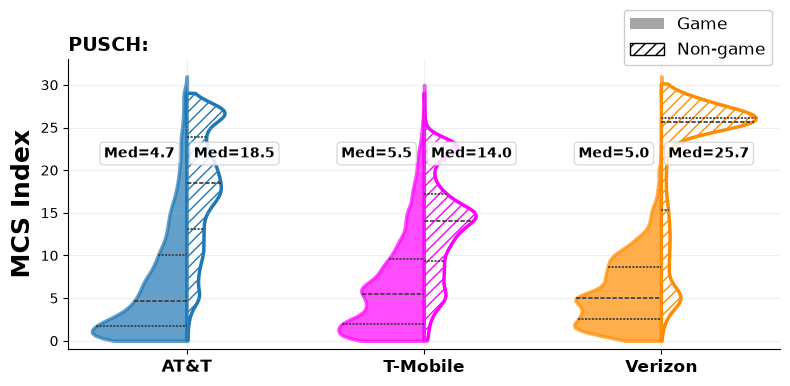

In [11]:
# ==========================================
#               CONFIGURATION
# ==========================================
df_operate = look_pusch.copy() 
df_operate['PUSCH'] = ''

X_COL = 'Operator'
Y_METRIC_COL = 'MCS'
ROW_COL = 'PUSCH'

# Hardcoded Operator Color Map to keep your theme locked down
OP_COLOR_MAP = {'AT&T': 'tab:blue', 'T-Mobile': 'magenta', 'Verizon': 'darkorange'}

# Set the static sorting order matching your reference style
SORTED_OPERATORS = [op for op in ['AT&T', 'T-Mobile', 'Verizon'] if op in df_operate[X_COL].unique()]
X_TO_COORD_MAP = {val: idx for idx, val in enumerate(SORTED_OPERATORS)}

row_categories = df_operate[ROW_COL].dropna().unique()
num_rows = len(row_categories)

# ==========================================
#          1. CREATE AXES GRID (OOP)
# ==========================================
fig, axes = plt.subplots(
    nrows=num_rows, 
    ncols=1, 
    figsize=(8, 4 * num_rows), # Slightly taller per row to match your aspect ratio
    sharex=True, 
    sharey=True
)

if num_rows == 1:
    axes = [axes]

# ==========================================
#          2. SUBPLOT LOOP LOGIC
# ==========================================
for ax, category in zip(axes, row_categories):
    df_sub = df_operate[df_operate[ROW_COL] == category]
    
    # Render base split distribution plot
    sns.violinplot(
        data=df_sub,
        x=X_COL,
        y=Y_METRIC_COL,
        hue='Label',
        hue_order=['Game', 'Non-game'],
        order=SORTED_OPERATORS,  
        split=True,
        inner='quartile',
        cut=0,
        ax=ax
    )
    
    # -----------------------------------------------------------------
    # 2. FIXED PRIMITIVE PATCHING & HATCHING (Missing-Data Proof!)
    # -----------------------------------------------------------------
    violins = [art for art in ax.collections if isinstance(art, plt.matplotlib.collections.PolyCollection)]
    
    for i, violin in enumerate(violins):
        # Find the physical X-axis center coordinate of this specific shape
        x_center = violin.get_paths()[0].vertices[:, 0].mean()
        op_idx = int(round(x_center)) # Converts 0.15 or -0.15 down to 0, 1, 2...
        
        # Guard rail just in case index goes out of range
        if op_idx < 0 or op_idx >= len(SORTED_OPERATORS):
            continue
            
        op_name = SORTED_OPERATORS[op_idx]
        op_color = OP_COLOR_MAP[op_name]
        
        # Set the outline color to the Operator Color
        violin.set_edgecolor(op_color)
        violin.set_linewidth(2.5)
        
        # Determine Left vs Right based on whether its path center is left or right of the tick mark
        is_left_side = (x_center < op_idx)
        
        # Left side (Game) -> Solid fill
        if is_left_side:
            violin.set_facecolor(op_color) 
            violin.set_alpha(0.7)
        # Right side (Non-game) -> White background with Hatches
        else:
            violin.set_facecolor('white')  
            violin.set_hatch('///')        
            violin.set_alpha(1.0)          
    
    # -----------------------------------------------------------------
    # --- Dynamic Split Annotation Text with Bounding Boxes ---
    # -----------------------------------------------------------------
    sub_x_values = df_sub[X_COL].dropna().unique()
    
    for x_value in sub_x_values:
        if x_value not in X_TO_COORD_MAP:
            continue
        x_idx = X_TO_COORD_MAP[x_value]
        
        y_pos = ax.get_ylim()[1] * 0.7
        
        df_left = df_sub[(df_sub[X_COL] == x_value) & (df_sub['Label'] == 'Game')]
        left_med = df_left[Y_METRIC_COL].median()
        left_count = df_left[Y_METRIC_COL].count()

        df_right = df_sub[(df_sub[X_COL] == x_value) & (df_sub['Label'] == 'Non-game')]
        right_med = df_right[Y_METRIC_COL].median()
        right_count = df_right[Y_METRIC_COL].count()

        # # Build strings
        # left_str = f"Med={left_med:.1f}\nn={left_count}" if left_count > 0 else ""
        # right_str = f"Med={right_med:.1f}\nn={right_count}" if right_count > 0 else ""


        # Build strings
        left_str = f"Med={left_med:.1f}" if left_count > 0 else ""
        right_str = f"Med={right_med:.1f}" if right_count > 0 else ""

        # DYNAMIC BOX CONFIGURATION
        # We use a semi-transparent white background with a thin gray border
        box_style = dict(
            boxstyle='round,pad=0.3', 
            facecolor='white', 
            edgecolor='lightgray', 
            alpha=0.85, 
            linewidth=1
        )

        # Left Text Node
        ax.text(
            x=x_idx - 0.2, 
            y=y_pos, 
            s=left_str, 
            color='black', 
            fontsize=10, 
            ha='center', 
            va='top', 
            fontweight='bold',
            bbox=box_style if left_count > 0 else None  # <-- Add box if data exists
        )
        
        # Right Text Node
        ax.text(
            x=x_idx + 0.2, 
            y=y_pos, 
            s=right_str, 
            color='black', 
            fontsize=10, 
            ha='center', 
            va='top', 
            fontweight='bold',
            bbox=box_style if right_count > 0 else None  # <-- Add box if data exists
        )
    
    # --- Standardizing Fonts & Axis Styling ---
    ax.set_title(f"{ROW_COL}: {category}", loc='left', fontsize=14, fontweight='bold')
    ax.set_xlabel('', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'{Y_METRIC_COL} Index', fontsize=18, fontweight='bold')
    ax.set_ylim(-1, 33) 
    ax.grid(True, alpha=0.2)
    ax.legend().remove() # Clear out individual subplot legends

    # BOLD AND RESIZE THE XTICKS HERE
    ax.tick_params(axis='x', which='major', labelsize=12)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

# ==========================================
#          3. GLOBAL CUSTOM LEGEND
# ==========================================
# Build custom legend keys to match your hatching pattern exactly
white_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Non-game')
gd_patch = mpatches.Patch(facecolor='gray', alpha=0.7, label='Game')

# Apply unified labels to the top axis
leg = axes[0].legend(handles=[gd_patch, white_patch], loc='upper right', prop={'size': 12}, bbox_to_anchor=(1, 1.2))
leg.get_frame().set_alpha(1.0)
leg.get_frame().set_facecolor('white')

sns.despine()
fig.tight_layout()

# Save using configuration variables
fig.savefig(OUTPUT_DIR / f'phy_{Y_METRIC_COL}-{ROW_COL}-{X_COL}-wise_violin.pdf', format='pdf', dpi=300, bbox_inches='tight')

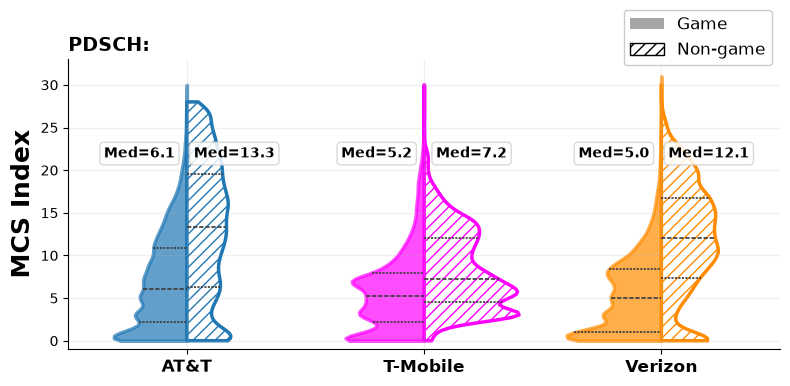

In [12]:
# ==========================================
#               CONFIGURATION
# ==========================================
df_operate = look_pdsch.copy() 
df_operate['PDSCH'] = ''

X_COL = 'Operator'
Y_METRIC_COL = 'MCS'
ROW_COL = 'PDSCH'

# Hardcoded Operator Color Map to keep your theme locked down
OP_COLOR_MAP = {'AT&T': 'tab:blue', 'T-Mobile': 'magenta', 'Verizon': 'darkorange'}

# Set the static sorting order matching your reference style
SORTED_OPERATORS = [op for op in ['AT&T', 'T-Mobile', 'Verizon'] if op in df_operate[X_COL].unique()]
X_TO_COORD_MAP = {val: idx for idx, val in enumerate(SORTED_OPERATORS)}

row_categories = df_operate[ROW_COL].dropna().unique()
num_rows = len(row_categories)

# ==========================================
#          1. CREATE AXES GRID (OOP)
# ==========================================
fig, axes = plt.subplots(
    nrows=num_rows, 
    ncols=1, 
    figsize=(8, 4 * num_rows), # Slightly taller per row to match your aspect ratio
    sharex=True, 
    sharey=True
)

if num_rows == 1:
    axes = [axes]

# ==========================================
#          2. SUBPLOT LOOP LOGIC
# ==========================================
for ax, category in zip(axes, row_categories):
    df_sub = df_operate[df_operate[ROW_COL] == category]
    
    # Render base split distribution plot
    sns.violinplot(
        data=df_sub,
        x=X_COL,
        y=Y_METRIC_COL,
        hue='Label',
        hue_order=['Game', 'Non-game'],
        order=SORTED_OPERATORS,  
        split=True,
        inner='quartile',
        cut=0,
        ax=ax
    )
    
    # -----------------------------------------------------------------
    # 2. FIXED PRIMITIVE PATCHING & HATCHING (Missing-Data Proof!)
    # -----------------------------------------------------------------
    violins = [art for art in ax.collections if isinstance(art, plt.matplotlib.collections.PolyCollection)]
    
    for i, violin in enumerate(violins):
        # Find the physical X-axis center coordinate of this specific shape
        x_center = violin.get_paths()[0].vertices[:, 0].mean()
        op_idx = int(round(x_center)) # Converts 0.15 or -0.15 down to 0, 1, 2...
        
        # Guard rail just in case index goes out of range
        if op_idx < 0 or op_idx >= len(SORTED_OPERATORS):
            continue
            
        op_name = SORTED_OPERATORS[op_idx]
        op_color = OP_COLOR_MAP[op_name]
        
        # Set the outline color to the Operator Color
        violin.set_edgecolor(op_color)
        violin.set_linewidth(2.5)
        
        # Determine Left vs Right based on whether its path center is left or right of the tick mark
        is_left_side = (x_center < op_idx)
        
        # Left side (Game) -> Solid fill
        if is_left_side:
            violin.set_facecolor(op_color) 
            violin.set_alpha(0.7)
        # Right side (Non-game) -> White background with Hatches
        else:
            violin.set_facecolor('white')  
            violin.set_hatch('///')        
            violin.set_alpha(1.0)          
    
    # -----------------------------------------------------------------
    # --- Dynamic Split Annotation Text with Bounding Boxes ---
    # -----------------------------------------------------------------
    sub_x_values = df_sub[X_COL].dropna().unique()
    
    for x_value in sub_x_values:
        if x_value not in X_TO_COORD_MAP:
            continue
        x_idx = X_TO_COORD_MAP[x_value]
        
        y_pos = ax.get_ylim()[1] * 0.7
        
        df_left = df_sub[(df_sub[X_COL] == x_value) & (df_sub['Label'] == 'Game')]
        left_med = df_left[Y_METRIC_COL].median()
        left_count = df_left[Y_METRIC_COL].count()

        df_right = df_sub[(df_sub[X_COL] == x_value) & (df_sub['Label'] == 'Non-game')]
        right_med = df_right[Y_METRIC_COL].median()
        right_count = df_right[Y_METRIC_COL].count()

        # # Build strings
        # left_str = f"Med={left_med:.1f}\nn={left_count}" if left_count > 0 else ""
        # right_str = f"Med={right_med:.1f}\nn={right_count}" if right_count > 0 else ""


        # Build strings
        left_str = f"Med={left_med:.1f}" if left_count > 0 else ""
        right_str = f"Med={right_med:.1f}" if right_count > 0 else ""

        # DYNAMIC BOX CONFIGURATION
        # We use a semi-transparent white background with a thin gray border
        box_style = dict(
            boxstyle='round,pad=0.3', 
            facecolor='white', 
            edgecolor='lightgray', 
            alpha=0.85, 
            linewidth=1
        )

        # Left Text Node
        ax.text(
            x=x_idx - 0.2, 
            y=y_pos, 
            s=left_str, 
            color='black', 
            fontsize=10, 
            ha='center', 
            va='top', 
            fontweight='bold',
            bbox=box_style if left_count > 0 else None  # <-- Add box if data exists
        )
        
        # Right Text Node
        ax.text(
            x=x_idx + 0.2, 
            y=y_pos, 
            s=right_str, 
            color='black', 
            fontsize=10, 
            ha='center', 
            va='top', 
            fontweight='bold',
            bbox=box_style if right_count > 0 else None  # <-- Add box if data exists
        )
    
    # --- Standardizing Fonts & Axis Styling ---
    ax.set_title(f"{ROW_COL}: {category}", loc='left', fontsize=14, fontweight='bold')
    ax.set_xlabel('', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'{Y_METRIC_COL} Index', fontsize=18, fontweight='bold')
    ax.set_ylim(-1, 33) 
    ax.grid(True, alpha=0.2)
    ax.legend().remove() # Clear out individual subplot legends

    # BOLD AND RESIZE THE XTICKS HERE
    ax.tick_params(axis='x', which='major', labelsize=12)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

# ==========================================
#          3. GLOBAL CUSTOM LEGEND
# ==========================================
# Build custom legend keys to match your hatching pattern exactly
white_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Non-game')
gd_patch = mpatches.Patch(facecolor='gray', alpha=0.7, label='Game')

# Apply unified labels to the top axis
leg = axes[0].legend(handles=[gd_patch, white_patch], loc='upper right', prop={'size': 12}, bbox_to_anchor=(1, 1.2))
leg.get_frame().set_alpha(1.0)
leg.get_frame().set_facecolor('white')

sns.despine()
fig.tight_layout()

# Save using configuration variables
fig.savefig(OUTPUT_DIR / f'phy_{Y_METRIC_COL}-{ROW_COL}-{X_COL}-wise_violin.pdf', format='pdf', dpi=300, bbox_inches='tight')

# F- Shuvo
**GOAL** Numbers of UL/DL MCS for Shuvo's draft

In [13]:
mcs_pdsch_sh = look_pdsch.groupby([
    # 'Test Status',
    'Label', 'Operator', 
    # 'PCell Band', 'PSCell Band',
    # 'RAN Configuration',
    'Technology',
    'Band Number'

])[[
    'MCS', 'BLER'

]].aggregate([
    'median',
    'count'

])
# display(mcs_pdsch)

mcs_pusch_sh = look_pusch.groupby([
    # 'Test Status',
    'Label', 'Operator', 
    # 'PCell Band', 'PSCell Band',
    # 'RAN Configuration',
    'Technology',
    'Band Number'

])[[
    'MCS'

]].aggregate([
    'median',
    'count'

])

print('='*60)
print('- '*12,'[Downlink]', '- '*11)
print('='*60)
print(mcs_pdsch_sh)

print('='*60)
print('- '*12,'[Uplink]', '- '*11)
print('='*60)        
print(mcs_pusch_sh)

- - - - - - - - - - - -  [Downlink] - - - - - - - - - - - 
                                            MCS           BLER       
                                         median  count  median  count
Label    Operator Technology Band Number                             
Game     AT&T     5G NR      5.0           7.80   8317     NaN      0
                  LTE        2.0           5.00  10917  0.0000  10919
                             4.0           8.50     80  0.0540     80
                             12.0          6.10   1583  0.0610   1583
                             30.0          5.00   7539  0.0000   7540
                             66.0          7.00   7387  0.0000   7389
         T-Mobile 5G NR      25.0          5.00   2149     NaN      0
                             41.0          6.60  12173     NaN      0
                             71.0         10.20    140     NaN      0
                  LTE        2.0           3.60   3076  0.0380   3077
                             66

In [14]:
mcs_pdsch_sh = look_pdsch.groupby([
    # 'Test Status',
    'Label', 'Operator', 
    # 'PCell Band', 'PSCell Band',
    # 'RAN Configuration',
    'Technology',
    # 'Band Number'

])[[
    'MCS', 'BLER'

]].aggregate([
    'median',
    'count'

])
# display(mcs_pdsch)

mcs_pusch_sh = look_pusch.groupby([
    # 'Test Status',
    'Label', 'Operator', 
    # 'PCell Band', 'PSCell Band',
    # 'RAN Configuration',
    'Technology',
    # 'Band Number'

])[[
    'MCS'

]].aggregate([
    'median',
    'count'

])

print('='*60)
print('- '*12,'[Downlink]', '- '*11)
print('='*60)
print(mcs_pdsch_sh)

print('='*60)
print('- '*12,'[Uplink]', '- '*11)
print('='*60)        
print(mcs_pusch_sh)

- - - - - - - - - - - -  [Downlink] - - - - - - - - - - - 
                                MCS          BLER       
                             median  count median  count
Label    Operator Technology                            
Game     AT&T     5G NR         7.8   8317    NaN      0
                  LTE           5.7  28002  0.000  28007
         T-Mobile 5G NR         6.4  14466    NaN      0
                  LTE           2.5   7031  0.000   7035
         Verizon  5G NR         6.5   7313    NaN      0
                  LTE           3.7  13716  0.000  13720
Non-game AT&T     5G NR         6.5   4619    NaN      0
                  LTE          14.9  20020  0.075  20033
         T-Mobile 5G NR         6.5   8013    NaN      0
                  LTE           6.5    511  0.076    511
         Verizon  5G NR         9.0   1063    NaN      0
                  LTE          13.7  13394  0.066  13394
- - - - - - - - - - - -  [Uplink] - - - - - - - - - - - 
                             